# Question 3 Random Walk Task

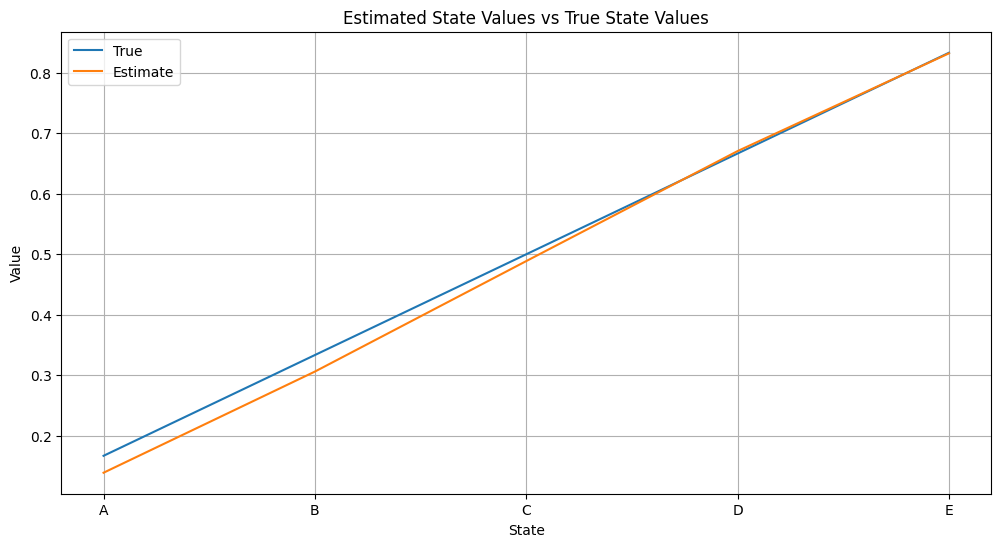

Error: 0.018308552543448483


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

class RandomWalk:
    def __init__(self):
        """Initialize the 5-state Random Walk MRP."""
        self.states = ['A', 'B', 'C', 'D', 'E']
        self.terminal_states = ['left_terminal', 'right_terminal']

        self.state = '0'

        self.left_action_map = {
            'A': "left_terminal",
            'B': 'A',
            'C': 'B',
            'D': 'C',
            'E': 'D'
        }

        self.right_action_map = {
            'A': 'B',
            'B': 'C',
            'C': 'D',
            'D': 'E',
            'E': "right_terminal"
        }

    def reset(self):
        """Reset the environment to the start state (C)."""
        # pass  # TODO: Implement state reset

        self.state = 'C'
        reward = 0
        done = False
        return self.state, reward, done

    
    def step(self, action):
        """Take a step in the environment.
        
        Args:
            action (int): -1 for left, +1 for right.
        
        Returns:
            next_state (str): The next state.
            reward (float): Reward received.
            done (bool): Whether the episode has ended.
        """
        # pass  # TODO: Implement transition dynamics

        self.state = self.left_action_map[self.state] if action == -1 else self.right_action_map[self.state]
        reward = 1 if self.state == "right_terminal" else 0
        done = True if self.state in self.terminal_states else False

        return self.state, reward, done


class TDLearner:
    def __init__(self, alpha=0.1, state_space = None, gamma = 1, init_value=0):
        """Initialize the TD(0) learning algorithm."""
        self.alpha = alpha
        self.gamma = gamma

        self.state_space = ["left_terminal", 'A', 'B', 'C', 'D', 'E', "right_terminal"] if state_space is None else state_space
        self.value_function = {s:init_value for s in self.state_space}
        self.value_function["left_terminal"] = 0
        self.value_function["right_terminal"] = 0
        
    
    def update(self, state, reward, next_state):
        """Perform a TD(0) update step.
        
        Args:
            state (str): Current state.
            reward (float): Reward received.
            next_state (str): Next state after transition.
        """
        # pass  # Implement TD(0) update rule
        # print(f"{state},{next_state}")
        self.value_function[state] = self.value_function[state] + self.alpha*(reward + self.gamma*self.value_function[next_state] - self.value_function[state])



def run_experiment(num_episodes=1000,seed=2025,alpha=0.1,init_value=0):
    """Run the Random Walk experiment with TD(0)."""
    env = RandomWalk()
    agent = TDLearner(alpha=alpha,init_value=init_value)
    np.random.seed(seed)

    all_rmse = []
    
    for episode in tqdm(range(num_episodes),desc="mc(0)",leave=False):
        state,reward,done = env.reset()
        done = False
        while not done:
            action = np.random.choice([-1, 1])  # Random left or right move
            next_state, reward, done = env.step(action)
            agent.update(state, reward, next_state)
            state = next_state

        temp_values = agent.value_function.copy()

        rmse = calculate_error(temp_values)
        all_rmse.append(rmse)
    
    return agent.value_function, all_rmse  # Return learned values

def plot_results(estimated_values: dict):
    """Plot estimated values against true values."""
    
    true_values = {
        "left_terminal": 0, 
        'A': 1/6, 
        'B': 2/6, 
        'C': 3/6, 
        'D': 4/6, 
        'E': 5/6, 
        "right_terminal": 1
    }

    true_values.pop("left_terminal","default")
    true_values.pop("right_terminal","default")
    estimated_values.pop("left_terminal","default")
    estimated_values.pop("right_terminal","default")

    fig, axs = plt.subplots(1,1,figsize=(12,6)) # was 2,1
    # fig.suptitle("Estimated State Values vs True State Values")

    axs.plot(true_values.values(), label="True")
    axs.plot(estimated_values.values(), label="Estimate")
    axs.grid()
    axs.set_title("Estimated State Values vs True State Values")
    axs.set_xticks(np.arange(len(estimated_values.keys())), labels=estimated_values.keys())
    axs.set_xlabel("State")
    axs.set_ylabel("Value")
    axs.legend()


    # im0 = axs[0].imshow(np.reshape(list(true_values.values()),(1,5)), cmap="YlGn", vmin=0, vmax=1)
    # axs[0].set_xticks(np.arange(len(true_values.keys())), labels=true_values.keys())
    # axs[0].set_yticks([], labels=[])
    # axs[0].set_title("True Values")

    # im1 = axs[1].imshow(np.reshape(list(estimated_values.values()),(1,5)), cmap="YlGn", vmin=0, vmax=1)
    # axs[1].set_xticks(np.arange(len(estimated_values.keys())), labels=estimated_values.keys())
    # axs[1].set_yticks([], labels=[])
    # axs[1].set_title("Estimated Values")
    # ax.set_ylabel("Player Sum")
    # ax.set_xlabel("Dealer Showing")

    # fig.colorbar(im0,label="State Value", orientation="vertical", location="right", ax=axs)
    # fig.tight_layout()
    plt.show()


def calculate_error(values: dict):
    true_values = {
        "left_terminal": 0, 
        'A': 1/6, 
        'B': 2/6, 
        'C': 3/6, 
        'D': 4/6, 
        'E': 5/6, 
        "right_terminal": 1
    }

    true_values.pop("left_terminal","default")
    true_values.pop("right_terminal","default")
    values.pop("left_terminal","default")
    values.pop("right_terminal","default")

    values = np.array(list(values.values()))
    true_values = np.array(list(true_values.values()))
    rmse = np.sqrt(np.mean((values-true_values)**2))

    return rmse

if __name__ == "__main__":
    estimated_values,_ = run_experiment(init_value=0.5)
    plot_results(estimated_values)
    print(f"Error: {calculate_error(estimated_values)}")

In [254]:
# Experiment 2: Alpha values

def generate_trajectory(env, max_steps=1000, seed = 2025):
    T = []

    s,_,_ = env.reset()
    for _ in range(max_steps):
        a = np.random.choice([-1, 1])
        next_s, reward, done = env.step(a) 

        T.append((s,a,next_s,reward,done))
        s = next_s

        if done:
            break

    return T

def run_MC_experiment(gamma = 1, episodes=10,seed=2025,alpha=0.1,init_value=0):
    value = {
        "left_terminal": 0, 
        'A': init_value, 
        'B': init_value, 
        'C': init_value, 
        'D': init_value, 
        'E': init_value, 
        "right_terminal": 0
    }

    env = RandomWalk()
    np.random.seed(seed)

    all_rmse = []

    for i in tqdm(range(episodes),desc="MC",leave=False):
        T = generate_trajectory(env)

        G = 0
        for j,transition in enumerate(reversed(T)):
            s,a,next_s,r,done = transition
            G = r + gamma*G
            if s not in [t[0] for t in T[0:len(T)-1-j]]:
                value[s] = value[s] + alpha*(G-value[s])

        rmse = calculate_error(value)
        all_rmse.append(rmse)


    return value, all_rmse




if __name__=="__main__":
    alphas = np.hstack((
        np.linspace(0,0.2,81),
        np.linspace(0.2,1,21)
    ))
    episodes = 100
    init_value = 0.5
    runs=10

    all_rmses_td = []
    all_rmses_mc = []

    for alpha in tqdm(alphas):
        
        current_run_all_rmse = []
        for i in range(runs):
            estimated_values, all_rmse = run_experiment(num_episodes=episodes,seed=2025+i,alpha=alpha,init_value=init_value)
            # print(f"2 {np.array(all_rmse).shape}")
            current_run_all_rmse.append(all_rmse)
        # print(f"1 {np.array(current_run_all_rmse).shape}")    
        array = np.array(current_run_all_rmse,dtype=float)
        # print(array.shape)  
        # print(np.mean(array,axis=0).shape)
        all_rmses_td.append(np.mean(array,axis=0))
        # print(len(all_rmses_td))

        current_run_all_rmse = []
        for i in range(runs):
            estimated_values, all_rmse = run_MC_experiment(episodes=episodes,seed=2025+i,alpha=alpha,init_value=init_value)
            current_run_all_rmse.append(all_rmse)
        array = np.array(current_run_all_rmse,dtype=float)
        all_rmses_mc.append(np.mean(array,axis=0))

        # plot_results(estimated_values)
        # tqdm.write(f"Alpha = {alpha} | Error: {error}")

100%|██████████| 102/102 [00:35<00:00,  2.89it/s]


TD: min 0.026888973457474877 at alpha = 0.05
MC: min 0.050843724577716416 at alpha = 0.04


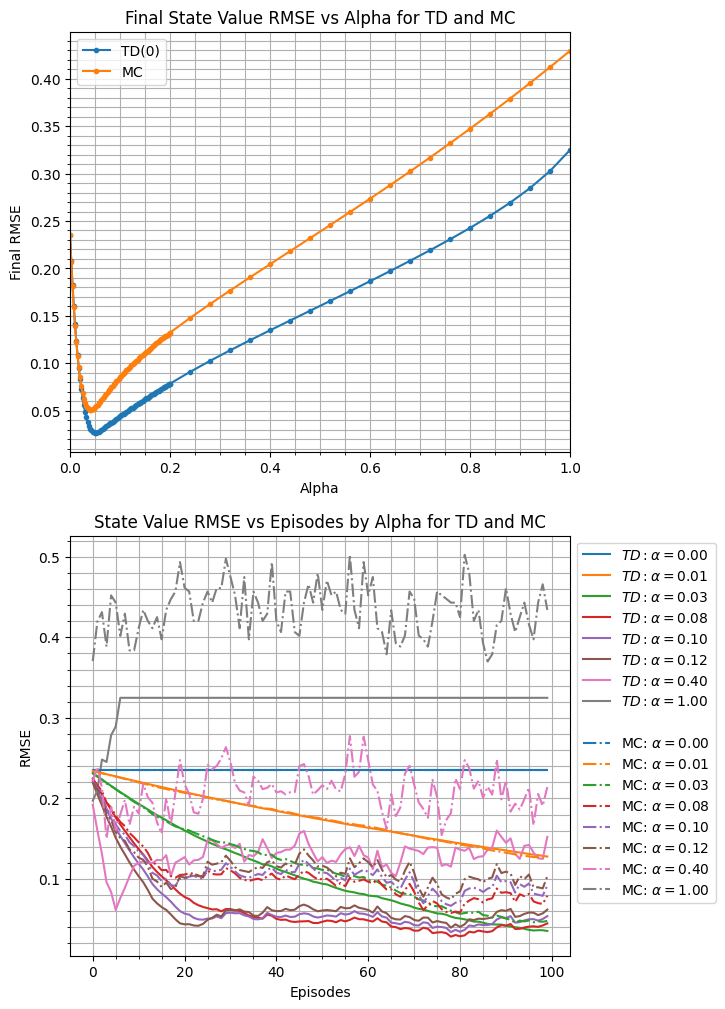

In [255]:
# Plotting
import matplotlib.colors as mcolors

# print(len(all_rmses_td))

num_pts_to_avg = 30
# print(np.array(all_rmses_td[:,-num_pts_to_avg-1:-1]).shape)
# print(np.mean(all_rmses_td[:,-num_pts_to_avg-1:-1],axis=1).shape)

all_rmses_td = np.array(all_rmses_td)
# print(np.shape(all_rmses_td))
# last_rmses_td = all_rmses_td[:,-1]
last_rmses_td = np.mean(all_rmses_td[:,-num_pts_to_avg-1:-1],axis=1)

all_rmses_mc = np.array(all_rmses_mc)
# print(np.shape(all_rmses_mc))
# last_rmses_mc = all_rmses_mc[:,-1]
last_rmses_mc = np.mean(all_rmses_mc[:,-num_pts_to_avg-1:-1],axis=1)


# print(list(all_errors))
fig, axs = plt.subplots(2,1,figsize=(8,12))




# print(alphas)
# print(last_rmses)

# for alpha,rmses in zip(alphas,all_rmses):
#     axs.plot(rmses, label=f"$\\alpha = {alpha:3.2f}$")
axs[0].plot(alphas, last_rmses_td, label=f"TD(0)", marker='.')
axs[0].plot(alphas, last_rmses_mc, label=f"MC", marker='.')
axs[0].grid(True, which="both")
axs[0].minorticks_on()
axs[0].set_title("Final State Value RMSE vs Alpha for TD and MC")
axs[0].set_xlabel("Alpha")
axs[0].set_ylabel("Final RMSE")
axs[0].legend(loc="upper left")
axs[0].set_xlim((0,1))




alphas_to_compare = [0, 0.01, 0.03, 0.08, 0.1, 0.12, 0.4, 1]
alpha_indices = [np.where(alphas == alpha_val)[0][0] for alpha_val in alphas_to_compare]
# print(alpha_indices)

colorlist = list(mcolors.TABLEAU_COLORS.keys())

for i in range(len(alphas_to_compare)):
    axs[1].plot(all_rmses_td[alpha_indices[i]], label=f"$TD: \\alpha = {alphas[alpha_indices[i]]:3.2f}$",color=colorlist[i])

axs[1].plot([0,0.001],[0.25,0.25],label=" ",color="white",marker="")

for i in range(len(alphas_to_compare)):
    axs[1].plot(all_rmses_mc[alpha_indices[i]], label=f"MC: $\\alpha = {alphas[alpha_indices[i]]:3.2f}$",color=colorlist[i],linestyle='-.')
    i+=1

axs[1].grid(True, which="both")
axs[1].minorticks_on()
axs[1].set_title("State Value RMSE vs Episodes by Alpha for TD and MC")
axs[1].set_xlabel("Episodes")
axs[1].set_ylabel("RMSE")
axs[1].legend(loc="upper left",bbox_to_anchor=(1, 1))

plt.subplots_adjust(right=0.75)
# axs[1].set_xlim((0,1))


min_rmse_td = np.min(last_rmses_td)
argmin_idx_rmse_td = np.argmin(last_rmses_td)
argmin_rmse_td = alphas[argmin_idx_rmse_td]

min_rmse_mc = np.min(last_rmses_mc)
argmin_idx_rmse_mc = np.argmin(last_rmses_mc)
argmin_rmse_mc = alphas[argmin_idx_rmse_mc]

print(f"TD: min {min_rmse_td} at alpha = {argmin_rmse_td}")
print(f"MC: min {min_rmse_mc} at alpha = {argmin_rmse_mc}")

In [155]:
x = np.linspace(1,10,100)
y = np.linspace(10,20,10)
z = np.hstack((x,y))
print(z.shape)

(110,)


# Question 4 Windy Gridworld Domain

In [256]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [299]:
class WindyGridWorld(object):
    def __init__(self, enable_king_move=False, enable_no_move=False, rendermode = None):
        # define the grid space
        self.grid = np.zeros((7, 10))

        # define the state space
        self.state_space = [[r, c] for r, c in zip(np.where(self.grid == 0.0)[0],
                                                   np.where(self.grid == 0.0)[1])]
        self.minbounds = [0,0]
        self.maxbounds = [6,9]

        # define the start state
        self.start_state = [3, 0]

        # define the goal state
        self.goal_state = [3, 7]

        # define the wind
        self.wind = np.array([0, 0, 0, 1, 1, 1, 2, 2, 1, 0], dtype=int)

        self.nprandom = np.random.default_rng()
        self.rendermode = rendermode

        # define the action space
        self.action_space = {
            "up": np.array([-1, 0]),
            "down": np.array([1, 0]),
            "left": np.array([0, -1]),
            "right": np.array([0, 1])
        }
        
        # Enable King's moves (Comment out the above action space to create a new one for King's moves)
        # if enable_king_move:
            
        #     if enable_no_move:
        #         #TODO
        #     else:
        #         #TODO
        #
        # else:
        #     #TODO
            
                
        # track the current state, time step, and action
        self.state = None
        self.t = None
        self.act = None

    def reset(self,seed = None):
        self.nprandom = np.random.default_rng(seed)
        # reset the agent to the start state
        self.state = self.start_state
        # reset the time step tracker
        self.t = 0
        # reset the action tracker
        self.act = None
        # reset the terminal flag
        terminated = False

        if self.rendermode == "human":
            self.render()

        return self.state, terminated

    def step(self, act):

        # Effect of action
        self.state += self.action_space[act]
        self.state = np.clip(self.state,self.minbounds,self.maxbounds)

        # Effect of wind by column
        self.state[0] -= self.wind[self.state[1]]
        self.state = np.clip(self.state,self.minbounds,self.maxbounds)

        # Clip state and force back into list
        self.state = list(self.state)

        # Termination and Reward
        if self.state == self.goal_state:
            reward = 0
            terminated = True
        else:
            reward = -1
            terminated = False

        if self.rendermode == "human":
            self.render()


        return self.state, reward, terminated

    def render(self):
        # plot the agent and the goal
        # agent = 1
        # goal = 2
        plot_arr = self.grid.copy()
        plot_arr[self.state[0], self.state[1]] = 1.0
        plot_arr[self.goal_state[0], self.goal_state[1]] = 2.0
        plt.clf()
        fig, arr = plt.subplots(1, 1)
        arr.set_title(f"state={self.state}, act={self.act}")
        arr.imshow(plot_arr)
        plt.show(block=False)
        plt.pause(1)
        plt.close(fig)


In [303]:
class SARSA(object):
    def __init__(self, env: WindyGridWorld, alpha, epsilon, gamma, timeout):
        """An agent that controls and learns using SARSA"""
        # define the parameters
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma
        
        

        # environment
        self.env = env

        # define the Q value table
        self.state_num = len(self.env.state_space)
        self.action_num = len(self.env.action_space.keys())
        self.Q = np.zeros((self.state_num, self.action_num))

        self.action_to_idx = {a:i for i,a in enumerate(list(self.env.action_space.keys()))}
        self.idx_to_action = {i:a for i,a in enumerate(list(self.env.action_space.keys()))}

        self.tuple_state_to_idx = {tuple(s):i for i,s in enumerate(list(self.env.state_space))}
        self.idx_to_state = {i:s for i,s in enumerate(list(self.env.state_space))}

        # define the timeout
        self.timeout = timeout

    def behavior_policy(self, state):
        """Return an action based on the state (epsilon soft)"""
        if self.env.nprandom.random() < self.epsilon:
            action = self.env.nprandom.choice(list(self.env.action_space.keys()))
        else:
            action = self.idx_to_action[np.argmax(self.Q[self.tuple_state_to_idx[tuple(state)],:])]

        return action

    def update(self, s, a, r, s_prime, a_prime):
        """Apply one update rule"""
        sidx = self.tuple_state_to_idx[tuple(s)]
        spidx = self.tuple_state_to_idx[tuple(s_prime)]

        aidx = self.action_to_idx[a]
        apidx = self.action_to_idx[a_prime]

        self.Q[sidx,aidx] = self.Q[sidx,aidx] + self.alpha*(r + self.gamma* self.Q[spidx,apidx] - self.Q[sidx,aidx])
        return self.Q[sidx,aidx]

    # def rollout(self,max_steps=1000,seed=None):
    #     """Generate a trajectory"""
    #     T = []

    #     s,_,_ = self.env.reset(seed=seed)
    #     for _ in tqdm(range(max_steps),desc="Rollout",leave=False,position=2):
    #         a = np.random.choice([-1, 1])
    #         next_s, reward, done = self.env.step(a) 

    #         T.append((s,a,next_s,reward,done))
    #         s = next_s

    #         if done:
    #             break

    #     return T

    def run(self,seed = None):
        """Run the algorithm stepwise"""

        done = True
        num_episodes_completed = -1
        list_num_epiodes = []
        for steps_taken in tqdm(range(self.timeout),desc="SARSA",leave=False,position=1):
            
            if done:
                # print(done)
                num_episodes_completed += 1
                state,done = self.env.reset(seed=seed)
                seed = seed + 1 if seed else None
                action = self.behavior_policy(state)
            
            next_state, reward, done = self.env.step(action)

            next_action = self.behavior_policy(next_state)

            self.update(state, action, reward, next_state, next_action)

            state = next_state
            action = next_action

            list_num_epiodes.append(num_episodes_completed)
            
        return list_num_epiodes

In [324]:
class ExpectedSARSA(object):
    def __init__(self, env: WindyGridWorld, alpha, epsilon, gamma, timeout):
        # define the parameters
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma

        # environment
        self.env = env

        # define the Q value table
        self.state_num = len(self.env.state_space)
        self.action_num = len(self.env.action_space.keys())
        self.Q = np.zeros((self.state_num, self.action_num))

        self.action_to_idx = {a:i for i,a in enumerate(list(self.env.action_space.keys()))}
        self.idx_to_action = {i:a for i,a in enumerate(list(self.env.action_space.keys()))}

        self.tuple_state_to_idx = {tuple(s):i for i,s in enumerate(list(self.env.state_space))}
        self.idx_to_state = {i:s for i,s in enumerate(list(self.env.state_space))}

        # define the timeout
        self.timeout = timeout

    def behavior_policy(self, state):
        """Return an action based on the state (epsilon soft)"""
        if self.env.nprandom.random() < self.epsilon:
            action = self.env.nprandom.choice(list(self.env.action_space.keys()))
        else:
            action = self.idx_to_action[np.argmax(self.Q[self.tuple_state_to_idx[tuple(state)],:])]

        return action

    def update(self, s, a, r, s_prime):
        """Apply one update rule"""
        sidx = self.tuple_state_to_idx[tuple(s)]
        spidx = self.tuple_state_to_idx[tuple(s_prime)]

        aidx = self.action_to_idx[a]

        Qs = self.Q[spidx,:]
        greedy_action = np.where(Qs == np.max(Qs))[0][0]
        
        probs = np.array([1-self.epsilon+self.epsilon/self.action_num if actionidx == greedy_action else self.epsilon/self.action_num for actionidx in range(self.action_num)])
        eQs = np.dot(probs,self.Q[spidx,:]) #TODO: check

        self.Q[sidx,aidx] = self.Q[sidx,aidx] + self.alpha*(r + self.gamma*eQs - self.Q[sidx,aidx])
        return self.Q[sidx,aidx]
    
    def rollout(self):
        pass

    def run(self,seed = None):
        """Run the algorithm stepwise"""

        done = True
        num_episodes_completed = -1
        list_num_epiodes = []
        for steps_taken in tqdm(range(self.timeout),desc="Expected SARSA",leave=False,position=1):
            
            if done:
                # print(done)
                num_episodes_completed += 1
                state,done = self.env.reset(seed=seed)
                seed = seed + 1 if seed else None
                
            action = self.behavior_policy(state)
            
            next_state, reward, done = self.env.step(action)

            self.update(state, action, reward, next_state)

            state = next_state

            list_num_epiodes.append(num_episodes_completed)
            
        return list_num_epiodes

In [335]:
class QLearning(object):
    def __init__(self, env, alpha, epsilon, gamma, timeout):
        # define the parameters
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma

        # environment
        self.env = env

        # define the Q value table
        self.state_num = len(self.env.state_space)
        self.action_num = len(self.env.action_space.keys())
        self.Q = np.zeros((self.state_num, self.action_num))

        self.action_to_idx = {a:i for i,a in enumerate(list(self.env.action_space.keys()))}
        self.idx_to_action = {i:a for i,a in enumerate(list(self.env.action_space.keys()))}

        self.tuple_state_to_idx = {tuple(s):i for i,s in enumerate(list(self.env.state_space))}
        self.idx_to_state = {i:s for i,s in enumerate(list(self.env.state_space))}

        # define the timeout
        self.timeout = timeout

    def behavior_policy(self, state):
        """Return an action based on the state (epsilon soft)"""
        if self.env.nprandom.random() < self.epsilon:
            action = self.env.nprandom.choice(list(self.env.action_space.keys()))
        else:
            action = self.idx_to_action[np.argmax(self.Q[self.tuple_state_to_idx[tuple(state)],:])]

        return action

    def update(self, s, a, r, s_prime):
        """Apply one update rule"""
        sidx = self.tuple_state_to_idx[tuple(s)]
        spidx = self.tuple_state_to_idx[tuple(s_prime)]

        aidx = self.action_to_idx[a]

        Qsp = self.Q[spidx,:]
        maxQsp = np.max(Qsp)

        self.Q[sidx,aidx] = self.Q[sidx,aidx] + self.alpha*(r + self.gamma*maxQsp - self.Q[sidx,aidx])
        return self.Q[sidx,aidx]

    def rollout(self):
        pass

    def run(self, seed = None):
        """Run the algorithm stepwise"""

        done = True
        num_episodes_completed = -1
        list_num_epiodes = []
        for steps_taken in tqdm(range(self.timeout),desc="Q-Learning",leave=False,position=1):
            
            if done:
                # print(done)
                num_episodes_completed += 1
                state,done = self.env.reset(seed=seed)
                seed = seed + 1 if seed else None
                
            action = self.behavior_policy(state)
            
            next_state, reward, done = self.env.step(action)

            self.update(state, action, reward, next_state)

            state = next_state

            list_num_epiodes.append(num_episodes_completed)
            
        return list_num_epiodes

In [268]:
def plot_curves(arr_list, legend_list, color_list, ylabel):
    """
    Args:
        arr_list (list): list of results arrays to plot
        legend_list (list): list of legends corresponding to each result array
        color_list (list): list of color corresponding to each result array
        ylabel (string): label of the Y axis

    Make sure the elements in the arr_list, legend_list, and color_list are associated with each other correctly.
    Do not forget to change the ylabel for different plots.
    """
    # Clear the current figure
    plt.clf()
    fig, ax = plt.subplots(figsize=(12, 8))

    # Set labels
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Time Steps")

    # Plot results
    h_list = []
    for arr, legend, color in zip(arr_list, legend_list, color_list):
        # Compute the mean and standard error while ignoring NaN values
        mean_arr = np.nanmean(arr, axis=0)
        arr_err = np.nanstd(arr, axis=0) / np.sqrt(np.sum(~np.isnan(arr), axis=0))
        
        # Plot the mean
        h, = ax.plot(range(len(mean_arr)), mean_arr, color=color, label=legend)
        
        # Plot the confidence band
        arr_err = 1.96 * arr_err  # 95% confidence interval
        ax.fill_between(range(len(mean_arr)),
                        mean_arr - arr_err,
                        mean_arr + arr_err,
                        alpha=0.3, color=color)
        # Save the plot handle
        h_list.append(h)

    # Set the title (adjust as needed)
    ax.set_title("Windy Gridworld Results")
    ax.legend(handles=h_list)
    plt.show()

In [336]:
def run_on_policy_td_control(run_num, timeout, start_seed = None, rendermode = None):
    
    enable_king_move_actions = False
    enable_no_move_actions = False
    
    # create the environment
    env = WindyGridWorld(enable_king_move=enable_king_move_actions, enable_no_move=enable_no_move_actions, rendermode=rendermode)

    # parameters
    epsilon = 0.1
    alpha = 0.5
    gamma = 1.0

    # create the SARSA
    sarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: SARSA",leave=True, position=0):
        # run for each trial
        controller_sarsa = SARSA(env, alpha, epsilon, gamma, timeout)
        episodes = controller_sarsa.run(seed=seed)
        # append the results
        sarsa_results_list.append(episodes[0:8000])
        seed += 1

    # create the expected SARSA
    expected_sarsa_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Expected SARSA",leave=True, position=0):
        # run for each trial
        controller_expected_sarsa = ExpectedSARSA(env, alpha, epsilon, gamma, timeout)
        episodes = controller_expected_sarsa.run(seed=seed)
        # append the results
        expected_sarsa_results_list.append(episodes[0:8000])
        seed += 1

    # create the Q learning
    q_learning_results_list = []
    seed = start_seed
    for _ in tqdm(range(run_num),desc="Experiment: Q-Learning",leave=True, position=0):
        # run for each trial
        controller_q_learning = QLearning(env, alpha, epsilon, gamma, timeout)
        episodes = controller_q_learning.run()
        # append the results
        q_learning_results_list.append(episodes[0:8000])
        seed += 1
    
    sarsa_array = np.array(sarsa_results_list)
    expected_sarsa_array = np.array(expected_sarsa_results_list)
    q_learning_array = np.array(q_learning_results_list)
    
    # Plot the results
    plot_curves(
        [sarsa_array, expected_sarsa_array, q_learning_array],
        ['SARSA', 'Expected SARSA', 'Q-learning'],
        ['r', 'b', 'g'],
        "Episodes"
    )

Experiment: Q-Learning: 100%|██████████| 10/10 [00:01<00:00,  5.47it/s]


<Figure size 640x480 with 0 Axes>

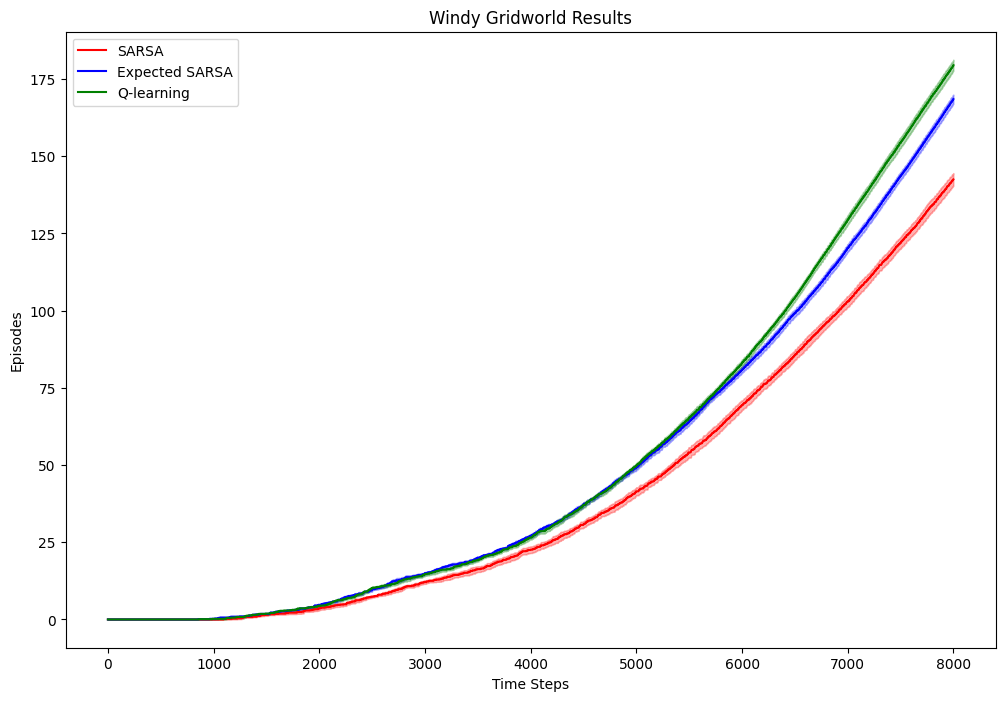

In [337]:
if __name__ == "__main__":
    # set randomness
    seed = 1234
    np.random.seed(seed)
    random.seed(seed)

    # trial number
    trial_num = 10
    # maximal time steps
    max_time_steps = 8000
    
    
    # run SARSA and Q Learning
    run_on_policy_td_control(trial_num, max_time_steps, start_seed=seed, rendermode = None)

# Question 4
- Please refer to starter code from question 4 to help you get started. You will create your own TD(0) and Monte Carlo classes.
- We will continue with the original windy gridworld domain. 
- A fixed policy π will be specified to collect episodes.
- A certain number of “training” episodes N ∈ {1, 10, 50} will be collected.
- Each method being investigated ( On-policy TD(0), On-policy Monte-Carlo prediction) will learn to      estimate the state-value.
function using the N “training“ episodes, respectively.
- We then evaluate the distribution of learning targets each method experiences at a specified state S. In
this question, S is the initial state marked as S in the Example 6.5.
- To do so, you need to collect additional 100 “evaluation” episodes. Instead of using these to perform
further updates to the state-value function, we will instead evaluate the distribution of learning targets
V(S) based on the “evaluation” episodes. For example, TD(0) will experience a set of {R+ V(S′)} targets,
whereas Monte-Carlo will experience a set of {G} targets.
- Note that in practice you should pre-collect both the training and evaluation episodes for efficiency and to
ensure consistency while comparing between different methods.

In [ ]:
def run_on_policy_mc_td_epsilon_greedy_windy_gridworld():
    enable_king_move_actions = False
    enable_no_move_actions = False
    
    # create environments
    env = WindyGridWorld(enable_king_move=enable_king_move_actions,
                         enable_no_move=enable_no_move_actions)
    env.reset()

    #TODO

In [ ]:
if __name__ == "__main__":
    np.random.seed(1234)
    random.seed(1234)
    run_on_policy_mc_td_epsilon_greedy_windy_gridworld()